In [1]:
import cv2
import matplotlib.pyplot as plt
import argparse

In [2]:
trained_model = 'mobilnet'

if trained_model == 'coco':
    config_file = 'model/coco/ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt'
    frozen_model = 'model/coco/frozen_inference_graph.pb'
    file_name = 'model/coco/labels.txt'
elif trained_model == 'yolo':
    config_file = 'model/yolo/yolov2-tiny.cfg'
    frozen_model = 'model/yolo/yolov2-tiny.weights'
    file_name = 'model/yolo/object_detection_classes_yolov3.txt'
elif trained_model == 'mobilnet':
    config_file = 'model/mobilnet/deploy.prototxt'
    frozen_model = 'model/mobilnet/mobilenet_iter_73000.caffemodel'
    file_name = 'model/mobilnet/object_detection_classes_pascal_voc.txt'
elif trained_model == 'yolo3':
    config_file = 'model/yolo3/yolov3.cfg'
    frozen_model = 'model/yolo3/yolov3.weights'
    file_name = 'model/yolo3/yolov3.txt'

model = cv2.dnn.DetectionModel(frozen_model, config_file)

In [3]:
classLabels = []
with open(file_name, 'rt') as fpt:
    classLabels = fpt.read().rstrip('\n').split('\n')

In [4]:
print(classLabels)
print(len(classLabels))

['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
20


In [5]:
model.setInputSize(320, 320)
model.setInputScale(1.0/127.5)
model.setInputMean((127.5, 127.5, 127.5))
model.setInputSwapRB(True)

< cv2.dnn.Model 00000252440E9F90>

# Image - Object Detection with CV2

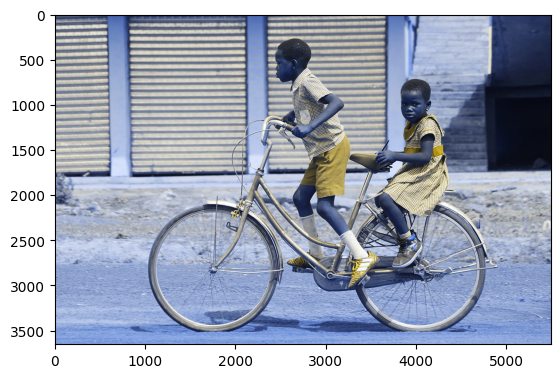

In [6]:
img = cv2.imread('images/boy.jpg')
plt.imshow(img)

In [7]:
ClassIndex, confidence, bbox = model.detect(img, confThreshold=0.55)
label_detected = [classLabels[i] for i in ClassIndex]
print(ClassIndex)

[15  2 15]


In [8]:
confidence

array([0.9993685 , 0.9986602 , 0.98633087], dtype=float32)

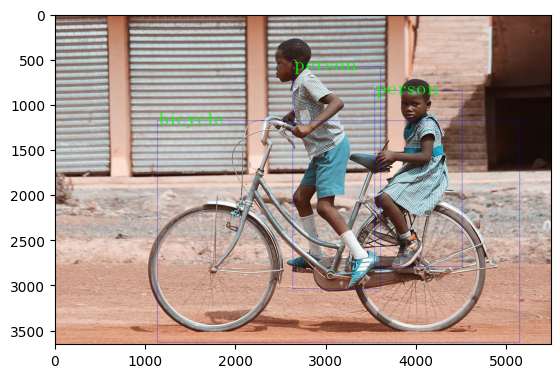

In [9]:
font_scale = 6
font = cv2.FONT_HERSHEY_TRIPLEX 
for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
  cv2.rectangle(img, boxes, (255, 0, 0), 2)
  cv2.putText(img, classLabels[ClassInd-1],
              (boxes[0]+10, boxes[1]+40), font, fontScale =  font_scale, color=(0,255,0), thickness=3)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
cv2.destroyAllWindows()

# Video Object Detection

In [10]:
cap = cv2.VideoCapture('videos/traffic.mp4')
if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Can't open the video")

font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN

while True:
    ret, frame = cap.read()

    ClassIndex, confidence, bbox = model.detect(frame, confThreshold=0.6)

    print(ClassIndex)

    if len(ClassIndex)!=0:
        for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
            if (ClassInd<=80):
                cv2.rectangle(frame, boxes, (255,0,0), 2)
                cv2.putText(frame, classLabels[ClassInd-1],
                            (boxes[0]+10, boxes[1]+40), font, fontScale =  font_scale, color=(0,255,0), thickness=3)
    
    cv2.imshow('objdetection by simple learn', frame) # Jupyter notebook
    if cv2.waitKey(2) & 0xff == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

[ 7 15]
[15  7]
[ 7 15]
[7]
[ 7 15]
[15  7]
[15  7]
[15  7]
[ 7 15]
[ 7 15]
[ 7 15]
[ 7 15]
[ 7 15]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7 6]
[7 6]
[7 6]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7 6]
[7 6]
[7]
[7]
[7]
[ 7 15]
[7]
[ 7 15]
[ 7 15]
[ 7 15]
[7]
[ 7 15]
[ 7 15]
[7]
[7]
[7]
[7]
[ 7 15]
[ 7 15]
[ 7 15]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[ 7 15]
[ 7 15]
[ 7 15]
[ 7 15]
[ 7 15]
[ 7 15]
[ 7 15]
[ 7 15]
[7]
[7]
[ 7 15]
[ 7 15]
[ 7 15]
[7]
[7]
[7]
[7]
[ 7 15]
[ 7 15]
[ 7 15]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7 6]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7 6]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7 6]
[7 7 6]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7 6]
[7 7 6]
[7 7 6]
[7 7 6]
[7 7 6]
[7 7 6]
[7 7]
[7 7]
[ 7  7 15]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 7]
[7 

# WebCam Object Detection

In [11]:
cap = cv2.VideoCapture(1)
if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Can't open the video")

font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN

while True:
    ret, frame = cap.read()

    ClassIndex, confidence, bbox = model.detect(frame, confThreshold=0.6)

    print(ClassIndex)

    if len(ClassIndex)!=0:
        for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
            if (ClassInd<=80):
                cv2.rectangle(frame, boxes, (255,0,0), 2)
                cv2.putText(frame, classLabels[ClassInd-1],
                            (boxes[0]+10, boxes[1]+40), font, fontScale =  font_scale, color=(0,255,0), thickness=3)
    
    cv2.imshow('objdetection by simple learn', frame) # Jupyter notebook
    if cv2.waitKey(2) & 0xff == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15  9]
[15]
[15]
[15]
[15  9]
[15]
[15]
[15]
[15]
[15]
[15  9]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[15]
[